<a href="https://colab.research.google.com/github/anudaindu/Mobitel_Alarm_Fault_Prediction/blob/main/notebooks/03_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Libraries for EDA

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully for EDA.")

Libraries imported successfully for EDA.


## Load Data

In [4]:
# Define the path to the processed dataset
input_file_path = '/content/drive/MyDrive/MobitelData/mobi_data2_processed.csv'

# Load the dataset. The file content was verified in the previous step.
df = pd.read_csv(input_file_path)
print(f"Dataset loaded successfully from: {input_file_path}")

# Display shape
print("\nShape of the dataset:", df.shape)

# Display data types and missing values
print("\nData types and non-null values:")
df.info()

# Display missing values count
print("\nMissing values per column:")
print(df.isnull().sum())

# Display duplicate rows count
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Display the first five rows
print("\nFirst five rows of the dataset:")
display(df.head())

/tmp/ipykernel_13264/1880629557.py:5: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(input_file_path)


Dataset loaded successfully from: /content/drive/MyDrive/MobitelData/mobi_data2_processed.csv

Shape of the dataset: (999999, 56)

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999999 entries, 0 to 999998
Data columns (total 56 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   occurred_on                      999999 non-null  object 
 1   alarm_id                         999999 non-null  int64  
 2   location_information             999999 non-null  object 
 3   additional_information           999999 non-null  object 
 4   received_on                      999999 non-null  object 
 5   enodeb_id                        999999 non-null  object 
 6   gnodeb_id                        999999 non-null  object 
 7   alarm_type_encoded               999999 non-null  int64  
 8   severity_encoded                 999999 non-null  int64  
 9   occurred_on_hour            

,occurred_on,alarm_id,location_information,additional_information,received_on,enodeb_id,gnodeb_id,alarm_type_encoded,severity_encoded,occurred_on_hour,...,previous_alarm_type_1,previous_alarm_type_2,previous_alarm_type_3,previous_alarm_type_4,previous_alarm_type_5,time_gap_previous_alarm,sequence_length,alarm_repeat_count,previous_cell_unavailable_count,target
0,2026-07-01 07:17:43,25888,"Link No.=70180, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 07:19:22,0,Unknown,4,3,7,...,-1,-1,-1,-1,-1,0.000000,0,0,0,0
1,2026-07-01 07:26:11,25888,"Link No.=70306, Description=eNodeB:MCC_413 MNC...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 07:27:51,0,Unknown,4,3,7,...,4,-1,-1,-1,-1,8.466667,1,1,0,0
2,2026-07-01 12:08:06,25888,"Link No.=70074, Description=eNodeB:MCC_413 MNC...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 12:09:46,0,Unknown,4,3,12,...,4,4,-1,-1,-1,281.916667,2,2,0,0
3,2026-07-01 18:50:12,65096,"Cabinet No.=0, Subrack No.=0, Slot No.=19, Por...","RAT_INFO=GUL, AFFECTED_RAT=GUL, DID=AUTODID_20...",2026-07-01 18:50:12,0,Unknown,8,3,18,...,4,4,4,-1,-1,402.100000,3,0,0,0
4,2026-07-01 21:45:56,25888,"Link No.=70182, Description=eNB:MCC_413 MNC_01...","RAT_INFO=GUL, AFFECTED_RAT=L, DID=AUTODID_2018...",2026-07-01 21:47:37,0,Unknown,4,3,21,...,8,4,4,4,-1,175.733333,4,3,0,0


## SECTION 1: Dataset Overview

### Objective
Display the dataset's shape, feature count, target distribution, and distinguish between numerical and categorical columns.

In [29]:
# Dataset Shape and Feature Count
print("Dataset Shape:", df.shape)
print("Total number of features (columns):", df.shape[1])

# Target Distribution
print("\nTarget (Cell Unavailable) Distribution:")
display(df['target'].value_counts())
display(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

# Identify Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical Columns (", len(numerical_cols), "):", numerical_cols)
print("Categorical Columns (", len(categorical_cols), "):", categorical_cols)

Dataset Shape: (999999, 56)
Total number of features (columns): 56

Target (Cell Unavailable) Distribution:


,count
target,
0,896827
1,103172


,proportion
target,
0,89.68%
1,10.32%



Numerical Columns ( 50 ): ['alarm_id', 'alarm_type_encoded', 'severity_encoded', 'occurred_on_hour', 'occurred_on_day', 'occurred_on_weekday', 'occurred_on_month', 'mo_name_encoded', 'alarm_name_encoded', 'alarm_duration_minutes', 'alarm_source_encoded', 'maintenance_status_encoded', 'ne_type_encoded', 'object_type_encoded', 'received_on_hour', 'received_on_day', 'received_on_weekday', 'received_on_month', 'subnet_encoded', 'type_encoded', 'previous_alarm_1', 'previous_alarm_2', 'previous_alarm_3', 'previous_alarm_4', 'previous_alarm_5', 'previous_severity_1', 'previous_severity_2', 'previous_severity_3', 'previous_severity_4', 'previous_severity_5', 'previous_alarm_source_1', 'previous_alarm_source_2', 'previous_alarm_source_3', 'previous_alarm_source_4', 'previous_alarm_source_5', 'previous_object_type_1', 'previous_object_type_2', 'previous_object_type_3', 'previous_object_type_4', 'previous_object_type_5', 'previous_alarm_type_1', 'previous_alarm_type_2', 'previous_alarm_type_3', 

### Interpretation

- **Dataset Shape:** The dataset contains `df.shape[0]` rows and `df.shape[1]` columns.
- **Missing Values & Duplicates:** There are no missing values or duplicate rows, indicating a clean dataset for analysis.
- **Initial Data Types:** The `df.info()` output shows a mix of numerical (`int64`, `float64`) and object (`object`) types. The 'object' columns typically represent categorical data or strings that may need further processing or encoding if they are not already encoded.

Now, let's explicitly look at the target distribution and column categorization.

### Target Distribution and Column Categorization


Target (Cell Unavailable) Distribution:
Value Counts:


,count
target,
0,896827
1,103172


Percentages:


,proportion
target,
0,89.68%
1,10.32%


/tmp/ipykernel_1565/3601930870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')


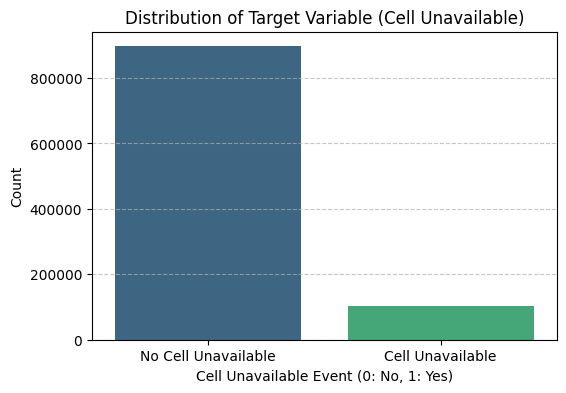


Numerical Columns ( 50 ): ['alarm_id', 'alarm_type_encoded', 'severity_encoded', 'occurred_on_hour', 'occurred_on_day', 'occurred_on_weekday', 'occurred_on_month', 'mo_name_encoded', 'alarm_name_encoded', 'alarm_duration_minutes', 'alarm_source_encoded', 'maintenance_status_encoded', 'ne_type_encoded', 'object_type_encoded', 'received_on_hour', 'received_on_day', 'received_on_weekday', 'received_on_month', 'subnet_encoded', 'type_encoded', 'previous_alarm_1', 'previous_alarm_2', 'previous_alarm_3', 'previous_alarm_4', 'previous_alarm_5', 'previous_severity_1', 'previous_severity_2', 'previous_severity_3', 'previous_severity_4', 'previous_severity_5', 'previous_alarm_source_1', 'previous_alarm_source_2', 'previous_alarm_source_3', 'previous_alarm_source_4', 'previous_alarm_source_5', 'previous_object_type_1', 'previous_object_type_2', 'previous_object_type_3', 'previous_object_type_4', 'previous_object_type_5', 'previous_alarm_type_1', 'previous_alarm_type_2', 'previous_alarm_type_3', 

In [32]:
# Target Distribution
print("\nTarget (Cell Unavailable) Distribution:")
target_counts = df['target'].value_counts()
target_percentages = df['target'].value_counts(normalize=True).mul(100).round(2)

print("Value Counts:")
display(target_counts)
print("Percentages:")
display(target_percentages.astype(str) + '%')

# Plot Target Distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=target_counts.index, y=target_counts.values, palette='viridis')
plt.title('Distribution of Target Variable (Cell Unavailable)')
plt.xlabel('Cell Unavailable Event (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Cell Unavailable', 'Cell Unavailable'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Identify Numerical and Categorical Columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("\nNumerical Columns (", len(numerical_cols), "):", numerical_cols)
print("Categorical Columns (", len(categorical_cols), "):", categorical_cols)

### Interpretation

- **Target Distribution:** The `target` variable shows the distribution of 'Cell Unavailable' events. This distribution will be crucial for understanding class imbalance.
- **Numerical vs. Categorical Columns:** The identified numerical columns include various encoded features and quantities, while categorical columns consist of original string-based identifiers and descriptions. This distinction is vital for applying appropriate EDA techniques.

## SECTION 2: Target Variable Analysis

### Objective
Analyze the target variable (`target`) to understand its distribution, percentage, and assess class imbalance. Explain whether the dataset is balanced.

/tmp/ipykernel_1565/1824104843.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='pastel')


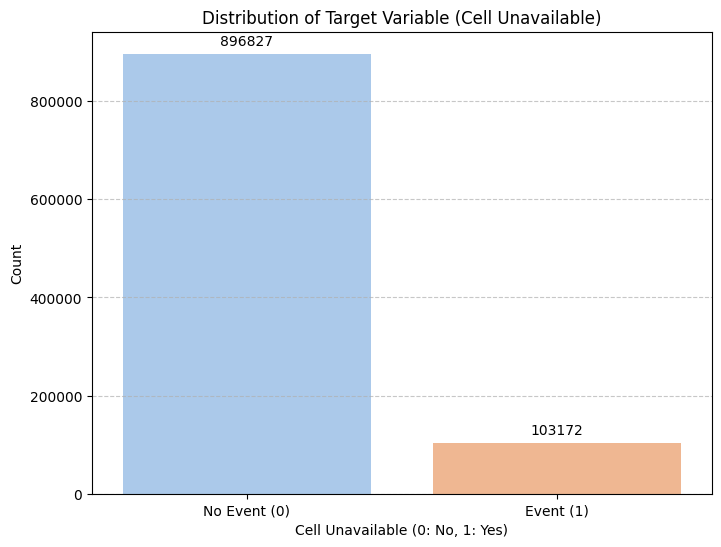


Target Variable Value Counts:


,count
target,
0,896827
1,103172



Target Variable Percentage Distribution:


,proportion
target,
0,89.68%
1,10.32%


In [33]:
# Show Count Plot and Percentage
plt.figure(figsize=(8, 6))
sns.countplot(x='target', data=df, palette='pastel')
plt.title('Distribution of Target Variable (Cell Unavailable)')
plt.xlabel('Cell Unavailable (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Event (0)', 'Event (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points')

plt.show()

print("\nTarget Variable Value Counts:")
display(df['target'].value_counts())

print("\nTarget Variable Percentage Distribution:")
display(df['target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

### Interpretation

- **Class Imbalance Assessment:** Based on the count plot and percentage distribution, we can determine if the dataset is balanced or imbalanced regarding the 'Cell Unavailable' events. If one class significantly outnumbers the other, it indicates class imbalance, which is a common challenge in predictive modeling, especially in early warning systems.

## SECTION 3: Alarm Frequency Analysis

### Objective
Analyze the `alarm_name_encoded` feature to identify and display the top 20 most frequently occurring alarms. Explain which alarms occur most frequently.

Top 20 Most Frequent Alarms (Encoded):


,count
alarm_name_encoded,
379,310249
273,169894
471,53581
473,38718
372,33842
111,32863
146,24223
472,19862
145,18641


/tmp/ipykernel_1565/3012490653.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_20_alarms.values, y=top_20_alarms.index.astype(str), palette='viridis')


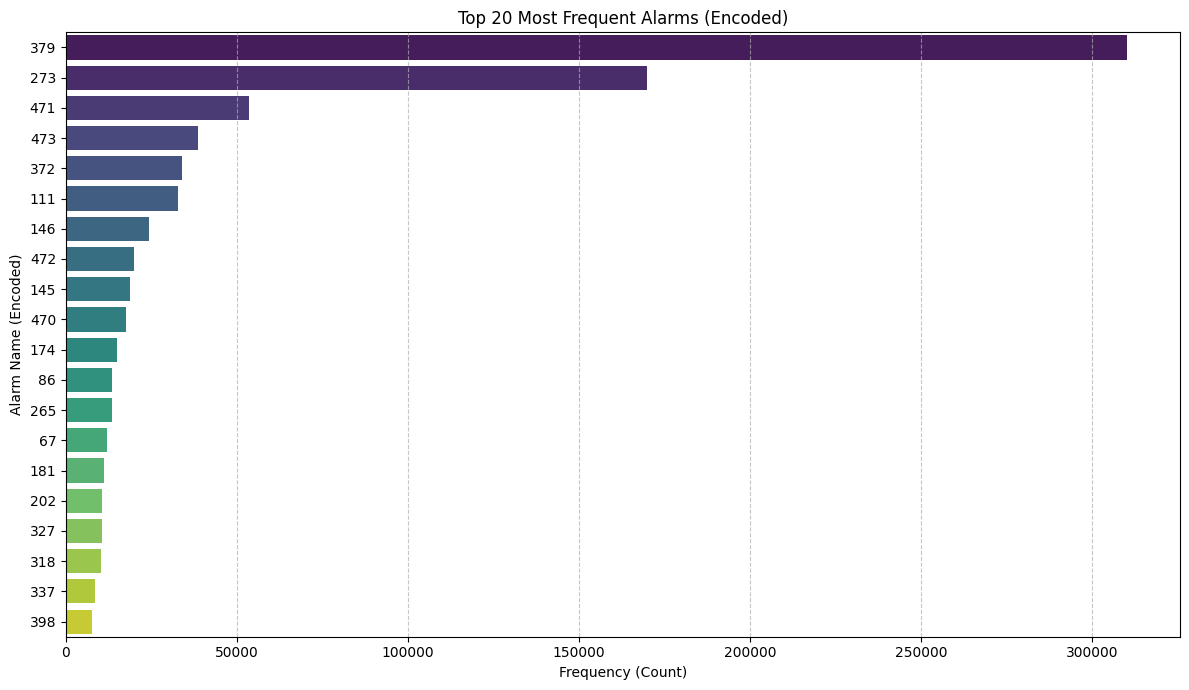

In [34]:
# Calculate the frequency of each alarm
alarm_frequency = df['alarm_name_encoded'].value_counts()

# Get the top 20 most frequent alarms
top_20_alarms = alarm_frequency.head(20)

print("Top 20 Most Frequent Alarms (Encoded):")
display(top_20_alarms)

# Visualization
plt.figure(figsize=(12, 7))
sns.barplot(x=top_20_alarms.values, y=top_20_alarms.index.astype(str), palette='viridis')
plt.title('Top 20 Most Frequent Alarms (Encoded)')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Name (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- The bar plot and the value counts table show the most common `alarm_name_encoded` values. These are the alarms that occur with the highest frequency in the dataset. Identifying these frequent alarms is crucial for understanding the most common issues that telecom towers face. Further investigation would involve mapping these encoded values back to their original alarm names to understand their practical implications.

## SECTION 4: Severity Analysis

### Objective
Analyze the `severity_encoded` feature by displaying its distribution and examining its relationship with the target variable ('Cell Unavailable').

Distribution of Severity Levels (Encoded):


,count
severity_encoded,
1,58501
2,69681
3,811583
4,60234


,proportion
severity_encoded,
3,81.16%
2,6.97%
4,6.02%
1,5.85%


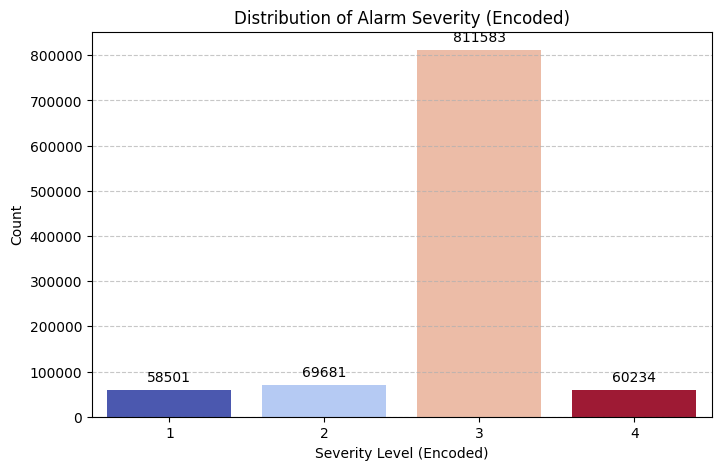


Severity vs Target (Cell Unavailable):


target,0,1
severity_encoded,,
1,95.13%,4.87%
2,82.66%,17.34%
3,90.93%,9.07%
4,75.67%,24.33%


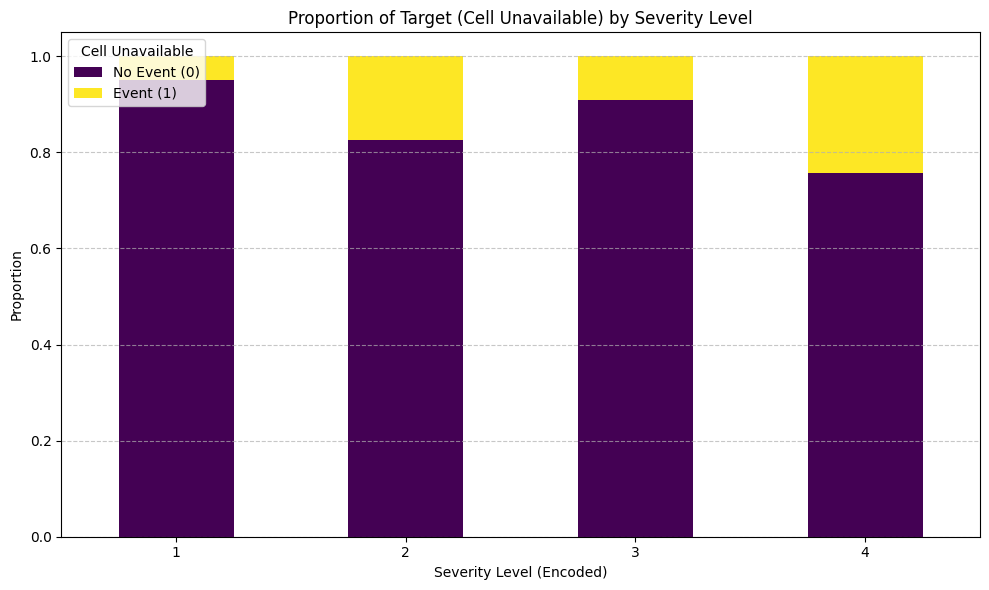

In [38]:
# 1. Distribution of Severity_encoded
print("Distribution of Severity Levels (Encoded):")
severity_counts = df['severity_encoded'].value_counts().sort_index()
severity_percentages = df['severity_encoded'].value_counts(normalize=True).mul(100).round(2)

display(severity_counts)
display(severity_percentages.astype(str) + '%')

plt.figure(figsize=(8, 5))
sns.barplot(x=severity_counts.index, y=severity_counts.values, hue=severity_counts.index, palette='coolwarm', legend=False)
plt.title('Distribution of Alarm Severity (Encoded)')
plt.xlabel('Severity Level (Encoded)')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center',
                       xytext=(0, 9),
                       textcoords='offset points')

plt.show()

# 2. Severity vs Target
print("\nSeverity vs Target (Cell Unavailable):")
severity_target = df.groupby('severity_encoded')['target'].value_counts(normalize=True).unstack().fillna(0)
display(severity_target.mul(100).round(2).astype(str) + '%')

severity_target.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Proportion of Target (Cell Unavailable) by Severity Level')
plt.xlabel('Severity Level (Encoded)')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(title='Cell Unavailable', labels=['No Event (0)', 'Event (1)'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- **Severity Distribution:** The distribution of `severity_encoded` reveals the most common severity levels of alarms in the dataset. This helps in understanding the general 'health' of the network or the types of alarms that are frequently triggered.
- **Severity vs. Target:** By analyzing the proportion of 'Cell Unavailable' events for each severity level, we can identify if certain severity levels are more predictive of a 'Cell Unavailable' event. For instance, if higher severity alarms correlate with a higher probability of the target event, it highlights their importance in the early warning system.

## SECTION 5: Alarm Source Analysis

### Objective
Analyze the `alarm_source_encoded` feature to identify and display the top alarm sources.

Top Alarm Sources (Encoded):


,count
alarm_source_encoded,
3699,168497
4915,31233
4914,20921
4922,15902
677,15519
4921,14538
506,11662
510,11627
1123,9413


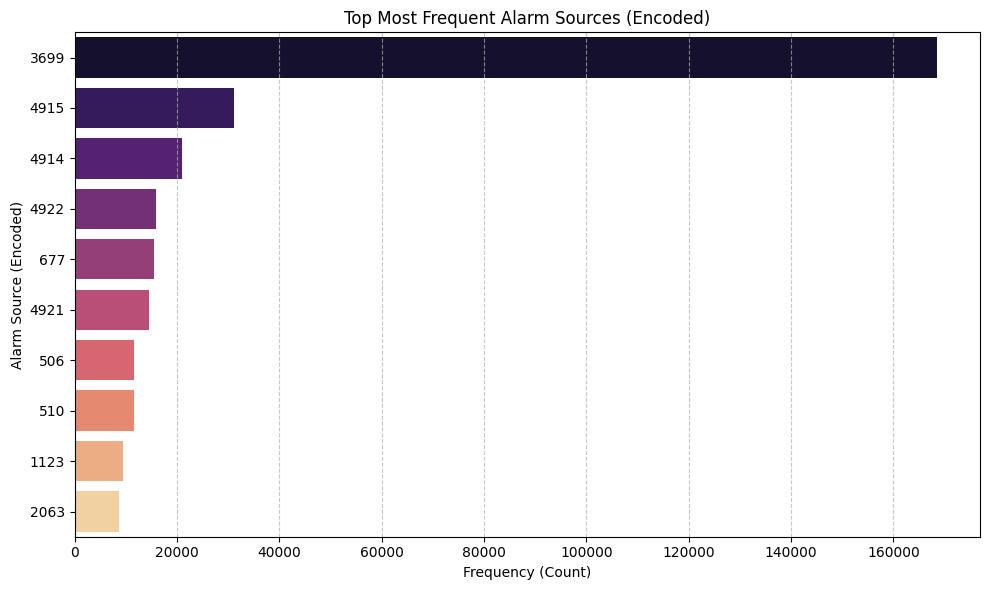

In [39]:
# Calculate the frequency of each alarm source
alarm_source_frequency = df['alarm_source_encoded'].value_counts()

# Get the top 10 (or desired number) most frequent alarm sources
top_alarm_sources = alarm_source_frequency.head(10)

print("Top Alarm Sources (Encoded):")
display(top_alarm_sources)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=top_alarm_sources.values, y=top_alarm_sources.index.astype(str), hue=top_alarm_sources.index.astype(str), palette='magma', legend=False)
plt.title('Top Most Frequent Alarm Sources (Encoded)')
plt.xlabel('Frequency (Count)')
plt.ylabel('Alarm Source (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- The bar plot and the value counts table highlight the most frequent `alarm_source_encoded` values. These represent the primary locations or components from which alarms originate. Understanding these sources can help in pinpointing problematic areas within the telecom network, allowing for targeted maintenance or system improvements. Further analysis would involve mapping these encoded values back to their original names.

## SECTION 6: Object Type Analysis

### Objective
Analyze the `object_type_encoded` feature and display its distribution.

Distribution of Object Types (Encoded):


,count
object_type_encoded,
34,311506
43,241266
1,214763
6,63138
3,55555
44,41982
32,19069
14,14983
20,11600


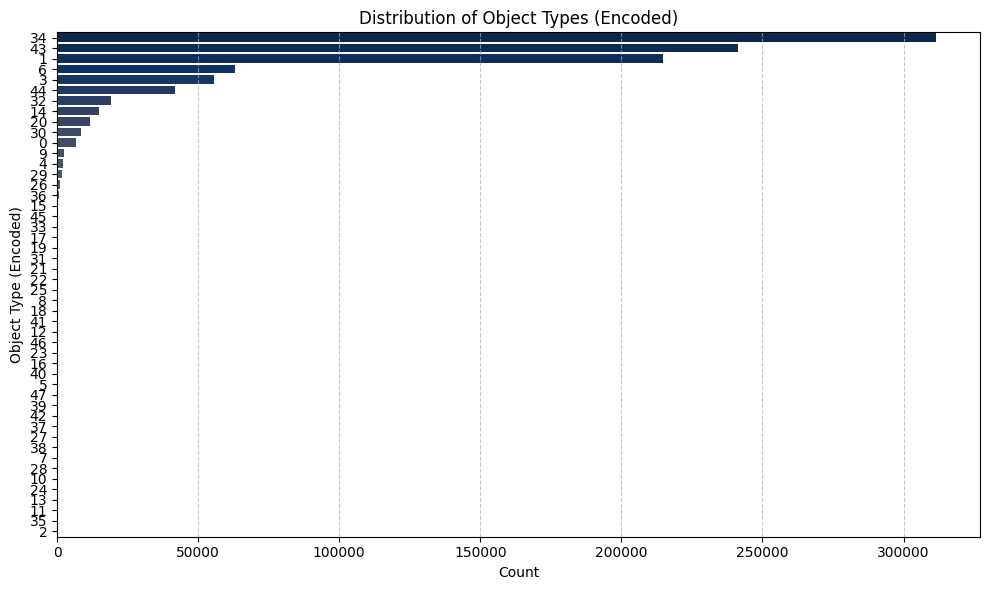

In [40]:
# Calculate the frequency of each object type
object_type_counts = df['object_type_encoded'].value_counts()

print("Distribution of Object Types (Encoded):")
display(object_type_counts)

# Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=object_type_counts.values, y=object_type_counts.index.astype(str), hue=object_type_counts.index.astype(str), palette='cividis', legend=False)
plt.title('Distribution of Object Types (Encoded)')
plt.xlabel('Count')
plt.ylabel('Object Type (Encoded)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation

- The distribution of `object_type_encoded` reveals the types of network objects most frequently associated with alarms. This information helps in understanding which components or entities within the telecom infrastructure are more prone to issues, guiding maintenance and resource allocation efforts. Mapping these encoded values to their actual object types would provide more concrete insights.

## SECTION 7: Sequence Length Analysis

### Objective
Analyze the `sequence_length` feature. This feature likely represents the number of alarms in a sequence leading up to an event. Display its distribution and identify typical sequence lengths.

In [ ]:
# Calculate the frequency of each sequence length
sequence_length_counts = df['sequence_length'].value_counts().sort_index()

print("Distribution of Sequence Lengths:")
display(sequence_length_counts)

# Visualization
plt.figure(figsize=(12, 6))
sns.barplot(x=sequence_length_counts.index, y=sequence_length_counts.values, hue=sequence_length_counts.index, palette='crest', legend=False)
plt.title('Distribution of Alarm Sequence Lengths')
plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Distribution of Sequence Lengths:


,count
sequence_length,
0,2991
1,2950
2,2905
3,2889
4,2869
...,...
425696,1
425697,1
425698,1


In [ ]:
# Boxplot for sequence_length to visualize its distribution and potential outliers
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['sequence_length'], palette='viridis')
plt.title('Boxplot of Sequence Length')
plt.xlabel('Sequence Length')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Interpretation
- The distribution of `sequence_length` indicates how many alarms typically precede a 'Cell Unavailable' event in a sequence. Understanding common sequence lengths can help in identifying patterns that lead to the target event. For example, a high frequency of shorter sequences might suggest immediate impact events, while longer sequences could indicate a deteriorating condition over time.

In [30]:
import os

file_path = '/content/drive/MyDrive/MobitelData/mobi_data2_processed.csv'

if os.path.exists(file_path):
    print(f"File exists at: {file_path}")
    try:
        with open(file_path, 'r') as f:
            print("\nFirst 5 lines of the file:")
            for i, line in enumerate(f):
                print(line.strip())
                if i == 4: # Print only the first 5 lines
                    break
    except Exception as e:
        print(f"Error reading file content: {e}")
else:
    print(f"File does NOT exist at: {file_path}. Please check the path and mount status of Google Drive.")

File exists at: /content/drive/MyDrive/MobitelData/mobi_data2_processed.csv

First 5 lines of the file:
occurred_on,alarm_id,location_information,additional_information,received_on,enodeb_id,gnodeb_id,alarm_type_encoded,severity_encoded,occurred_on_hour,occurred_on_day,occurred_on_weekday,occurred_on_month,mo_name_encoded,alarm_name_encoded,alarm_duration_minutes,alarm_source_encoded,maintenance_status_encoded,ne_type_encoded,object_type_encoded,received_on_hour,received_on_day,received_on_weekday,received_on_month,subnet_encoded,type_encoded,previous_alarm_1,previous_alarm_2,previous_alarm_3,previous_alarm_4,previous_alarm_5,previous_severity_1,previous_severity_2,previous_severity_3,previous_severity_4,previous_severity_5,previous_alarm_source_1,previous_alarm_source_2,previous_alarm_source_3,previous_alarm_source_4,previous_alarm_source_5,previous_object_type_1,previous_object_type_2,previous_object_type_3,previous_object_type_4,previous_object_type_5,previous_alarm_type_1,previous_